In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load data
fs = pd.read_csv('../data/OASIS3_Freesurfer_output.csv')
demo = pd.read_csv('../data/OASIS3_demographics.csv')
cdr = pd.read_csv('../data/OASIS3_UDSb4_cdr.csv')

print("FreeSurfer shape:", fs.shape)
print("Demographics shape:", demo.shape)
print("CDR shape:", cdr.shape)

print("\nCDR distribution:")
print(cdr['CDRTOT'].value_counts().sort_index())

print("\nDiagnosis distribution:")
print(cdr['dx1'].value_counts().head(10))

FreeSurfer shape: (2681, 203)
Demographics shape: (1378, 19)
CDR shape: (8626, 23)

CDR distribution:
CDRTOT
0.0    6479
0.5    1444
1.0     528
2.0     155
3.0      19
Name: count, dtype: int64

Diagnosis distribution:
dx1
Cognitively normal                  6401
AD Dementia                         1145
uncertain dementia                   475
Unc: ques. Impairment                 80
DLBD, primary                         48
AD dem w/depresss, not contribut      46
.                                     43
No dementia                           37
AD dem w/depresss, contribut          25
Vascular Demt, primary                24
Name: count, dtype: int64


In [2]:
# Get each subject's worst CDR score (most severe across all visits)
cdr_max = cdr.groupby('OASISID')['CDRTOT'].max().reset_index()
cdr_max.columns = ['OASISID', 'max_CDR']

# Create diagnostic groups
def cdr_group(cdr_val):
    if cdr_val == 0:
        return 'CN'
    elif cdr_val == 0.5:
        return 'MCI'
    elif cdr_val >= 1.0:
        return 'AD'

cdr_max['diagnosis_group'] = cdr_max['max_CDR'].apply(cdr_group)

# Merge with demographics
df = demo.merge(cdr_max, on='OASISID')

# Merge with FreeSurfer - use earliest scan per subject
fs_first = fs.sort_values('MR_session').groupby('Subject').first().reset_index()
fs_first = fs_first.rename(columns={'Subject': 'OASISID'})

# Final merged dataset
df_merged = df.merge(fs_first[['OASISID', 'TOTAL_HIPPOCAMPUS_VOLUME', 
                                 'lh_entorhinal_thickness', 'rh_entorhinal_thickness',
                                 'lh_precuneus_thickness', 'rh_precuneus_thickness',
                                 'IntraCranialVol', 'FS QC Status']], on='OASISID')

# Keep only QC passed
df_merged = df_merged[df_merged['FS QC Status'] == 'Passed']

print("Final dataset shape:", df_merged.shape)
print("\nDiagnosis group distribution:")
print(df_merged['diagnosis_group'].value_counts())

Final dataset shape: (960, 28)

Diagnosis group distribution:
diagnosis_group
CN     595
MCI    204
AD     160
Name: count, dtype: int64


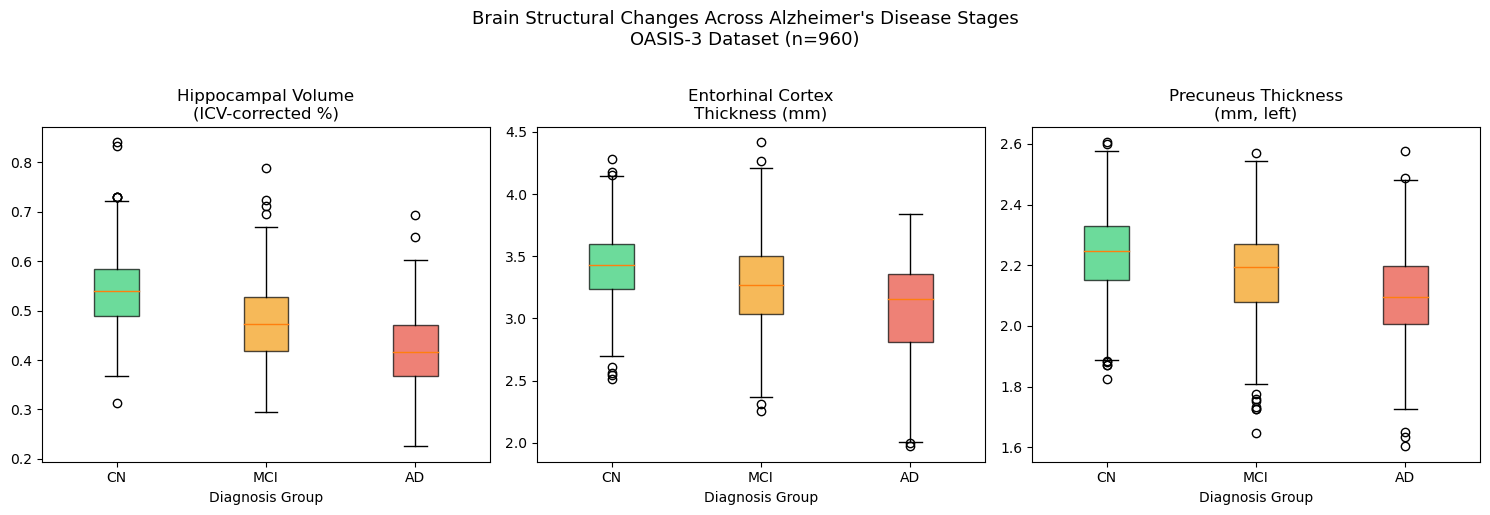

Plot saved.

Mean values by group:

Hippo Vol (%):
diagnosis_group
CN     0.5393
MCI    0.4792
AD     0.4208
Name: hippo_ICV_corrected, dtype: float64

Entorhinal thickness:
diagnosis_group
CN     3.4283
MCI    3.2694
AD     3.0704
Name: mean_entorhinal_thickness, dtype: float64


In [3]:
# ICV-correct hippocampal volume
df_merged['hippo_ICV_corrected'] = (df_merged['TOTAL_HIPPOCAMPUS_VOLUME'] / 
                                     df_merged['IntraCranialVol']) * 100

# Entorhinal thickness average
df_merged['mean_entorhinal_thickness'] = (df_merged['lh_entorhinal_thickness'] + 
                                           df_merged['rh_entorhinal_thickness']) / 2

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

regions = {
    'Hippocampal Volume\n(ICV-corrected %)': 'hippo_ICV_corrected',
    'Entorhinal Cortex\nThickness (mm)': 'mean_entorhinal_thickness',
    'Precuneus Thickness\n(mm, left)': 'lh_precuneus_thickness'
}

colors = {'CN': '#2ecc71', 'MCI': '#f39c12', 'AD': '#e74c3c'}
order = ['CN', 'MCI', 'AD']

for ax, (title, col) in zip(axes, regions.items()):
    data_by_group = [df_merged[df_merged['diagnosis_group'] == g][col].dropna() 
                     for g in order]
    bp = ax.boxplot(data_by_group, labels=order, patch_artist=True)
    for patch, group in zip(bp['boxes'], order):
        patch.set_facecolor(colors[group])
        patch.set_alpha(0.7)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Diagnosis Group')

plt.suptitle('Brain Structural Changes Across Alzheimer\'s Disease Stages\nOASIS-3 Dataset (n=960)', 
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../results/01_brain_structure_by_diagnosis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

# Print mean values
print("\nMean values by group:")
for col, label in [('hippo_ICV_corrected', 'Hippo Vol (%)'), 
                    ('mean_entorhinal_thickness', 'Entorhinal thickness')]:
    print(f"\n{label}:")
    print(df_merged.groupby('diagnosis_group')[col].mean().reindex(order).round(4))